In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec


import os

import seaborn as sns



## Load entropy results

In [2]:
# Load Cell Ranger  RNA filtering criteria barcodes
CR_rnamodality_BC_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/rna/VIB_10xmultiome_2_rna/outs/filtered_feature_bc_matrix/barcodes.tsv'
CR_rnamodality_bc = pd.read_csv(CR_rnamodality_BC_file, header=None, sep='\t', names=['barcodes'])

CR_rnamodality_bc['rna_bc'] = CR_rnamodality_bc['barcodes'].map(lambda x: x.split('-1')[0])


# Load Entropy value for each barcode on atac 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'chr1_barcode_entropy_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df['atac_bc'] = entropy_df.index.map(lambda x: x.split('-1')[0])



entropy_filtered_bc_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_filtered_bc_df = pd.read_csv(entropy_filtered_bc_file, sep=',', index_col=0)
entropy_filtered_bc_df['atac_bc'] = entropy_filtered_bc_df.index.map(lambda x: x.split('-1')[0])

# Load Entropy filtered atac barcodes
# Use entropy_peak.obs or peak.obs # TODO: Change to be entropy_passed barcodes file 

# Load  atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')




### Match RNA and ATAC abrcodes

In [3]:
bc_map = bc_map_pd.set_index('atac_barcodes')

if entropy_df.index.name != 'atac_barcodes':
    entropy_df.set_index('atac_bc', inplace=True)
    entropy_df.index.name = 'atac_barcodes'
    entropy_df['atac_bc'] = entropy_df.index.values
    
if 'rna_barcodes' not in entropy_df.columns:
    entropy_df = entropy_df.join(bc_map, how='inner')
    

entropy_df.shape

(33287, 9)

In [4]:
entropy_df['rna_pass_CR'] = entropy_df['rna_barcodes'].isin(CR_rnamodality_bc['rna_bc'])
entropy_df['atac_pass_entropy'] = entropy_df['atac_bc'].isin(entropy_filtered_bc_df['atac_bc'])

In [5]:
entropy_df.groupby([ 'atac_pass_entropy', 'rna_pass_CR']).size().unstack(fill_value=0)

rna_pass_CR,False,True
atac_pass_entropy,,
False,31044,117
True,138,1988


In [7]:
117 + 1988, 138 + 1988

(2105, 2126)

In [ ]:
1988 / (1988 + 117) # good RNA BCs recovery rate

0.9444180522565321

In [7]:
45828472 /60463080

0.7579579472299459

## Check Doublet score 

In [ ]:
# load AMULET doublet detection results
AMULET_doublet_file = os.path.join(entropy_dir, '_UnionBC_fragments/AMULET_output/MultipletProbabilities.txt')
AMULET_doublet_df = pd.read_csv(AMULET_doublet_file, sep='\t', index_col=0)
AMULET_doublet_df['atac_bc'] = AMULET_doublet_df.index.map(lambda x: x.split('-1')[0])
AMULET_doublet_df.reset_index(inplace=True, drop=False)
AMULET_doublet_df.set_index('atac_bc', inplace=True)
AMULET_doublet_df = AMULET_doublet_df.rename(columns={'p-value': 'AMULET_pvalue', 'q-value': 'AMULET_qvalue'}, inplace=False)

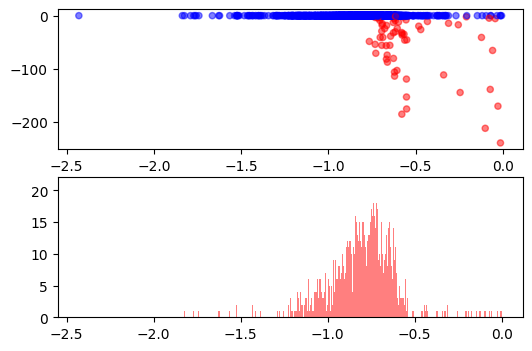

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(6, 4))
ax[0].scatter( h5_rna.obs['log10_Entropy'], np.log10(h5_rna.obs['AMULET_qvalue']), c=h5_rna.obs['AMULET_doublet'].map({True: 'red', False: 'blue'}), alpha=0.5, s=20)

_ = ax[1].hist(h5_rna.obs['log10_Entropy'], bins=100, alpha=0.5, label='Doublets', color='red')

In [44]:
h5_rna.obs.groupby(['AMULET_doublet', 'identified_by_atac']).size().unstack()

/tmp/ipykernel_223282/3685671454.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['AMULET_doublet', 'identified_by_atac']).size().unstack()


identified_by_atac,both,cr_only,entropy_only
AMULET_doublet,,,
False,1796,59,238
True,91,0,1
